In [1]:
import pandas as pd

In [2]:
reviews = pd.read_csv("../../datasets/reviews_athens.csv")

#### Preprocess 'reviews_athens.csv'

In [3]:
reviews.head()

,place_id,place_name,place_rating,place_address,place_types,location.lat,location.lng,place_user_ratings_total,user_name,user_rating,review_text,creation_time
0,ChIJXa9EhZajoRQRvI6l9_rat1U,ChrisAndro Apartments,4.7,"Pipinou 45, Athina","['lodging', 'point_of_interest', 'establishment']",38.013307,23.677931,55,Arthur Quing,5,Feels like I'm home. Our family loves the swim...,1682362247
1,ChIJXa9EhZajoRQRvI6l9_rat1U,ChrisAndro Apartments,4.7,"Pipinou 45, Athina","['lodging', 'point_of_interest', 'establishment']",38.013307,23.677931,55,M. K.,5,This is a hidden gem in the city. Great overni...,1704966677
2,ChIJXa9EhZajoRQRvI6l9_rat1U,ChrisAndro Apartments,4.7,"Pipinou 45, Athina","['lodging', 'point_of_interest', 'establishment']",38.013307,23.677931,55,Stefhanie de Kom,5,Very nice people. I was there just to visit my...,1600854102
3,ChIJXa9EhZajoRQRvI6l9_rat1U,ChrisAndro Apartments,4.7,"Pipinou 45, Athina","['lodging', 'point_of_interest', 'establishment']",38.013307,23.677931,55,yoel guenine,5,Amazing appartment full equipped.,1623825780
4,ChIJXa9EhZajoRQRvI6l9_rat1U,ChrisAndro Apartments,4.7,"Pipinou 45, Athina","['lodging', 'point_of_interest', 'establishment']",38.013307,23.677931,55,Kostas Gontikakis,5,The best place in Athens!,1607635402


In [4]:
reviews.count()

place_id                    5623
place_name                  5623
place_rating                5623
place_address               5622
place_types                 5623
location.lat                5623
location.lng                5623
place_user_ratings_total    5623
user_name                   5623
user_rating                 5623
review_text                 5623
creation_time               5623
dtype: int64

In [5]:
reviews.duplicated().value_counts()

False    5623
Name: count, dtype: int64

In [6]:
reviews.dropna(subset='review_text',inplace=True)
reviews.count()

place_id                    5623
place_name                  5623
place_rating                5623
place_address               5622
place_types                 5623
location.lat                5623
location.lng                5623
place_user_ratings_total    5623
user_name                   5623
user_rating                 5623
review_text                 5623
creation_time               5623
dtype: int64

#### Analyzing dataset

In [7]:
'Average Rating:',reviews['user_rating'].sum()/reviews['user_rating'].count()

('Average Rating:', 4.329895073804019)

In [8]:
reviews['review_text'].apply(len).mean()

363.8641294682554

In [9]:
reviews[reviews['user_rating'] >= 4].count()['user_rating']

4621

In [10]:
reviews[reviews['user_rating'] == 3].count()['user_rating']

323

In [11]:
reviews[reviews['user_rating'] < 3].count()['user_rating']

679

<Axes: >

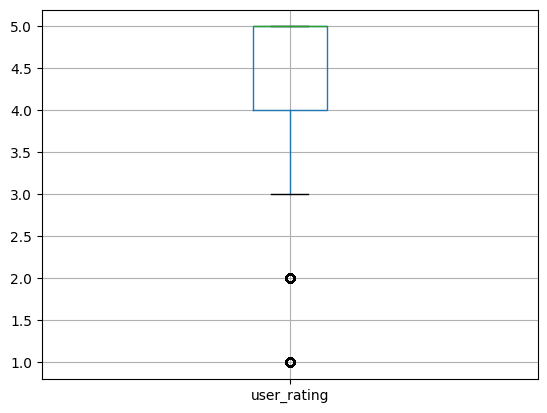

In [12]:
reviews.boxplot(column='user_rating')

#### NLTK Experimentation

In [13]:
import nltk

In [14]:
reviews['review_text'][0]

"Feels like I'm home. Our family loves the swimming pool. Very nice place,  shops can reach on foot. Niki is very accommodating. Will recommend this place.."

In [15]:
tokens = nltk.word_tokenize(reviews['review_text'][0])
print(tokens)

['Feels', 'like', 'I', "'m", 'home', '.', 'Our', 'family', 'loves', 'the', 'swimming', 'pool', '.', 'Very', 'nice', 'place', ',', 'shops', 'can', 'reach', 'on', 'foot', '.', 'Niki', 'is', 'very', 'accommodating', '.', 'Will', 'recommend', 'this', 'place', '..']


In [16]:
tagged = nltk.pos_tag(tokens)
print(tagged[:6])

[('Feels', 'NNS'), ('like', 'IN'), ('I', 'PRP'), ("'m", 'VBP'), ('home', 'NN'), ('.', '.')]


In [17]:
entities = nltk.chunk.ne_chunk(tagged)
print(entities)

(S
  Feels/NNS
  like/IN
  I/PRP
  'm/VBP
  home/NN
  ./.
  Our/PRP$
  family/NN
  loves/VBZ
  the/DT
  swimming/NN
  pool/NN
  ./.
  (PERSON Very/NNP)
  nice/JJ
  place/NN
  ,/,
  shops/NNS
  can/MD
  reach/VB
  on/IN
  foot/NN
  ./.
  (PERSON Niki/NNP)
  is/VBZ
  very/RB
  accommodating/VBG
  ./.
  Will/MD
  recommend/VB
  this/DT
  place/NN
  ../NN)


In [18]:
from nltk.tree import Tree
from IPython.display import display

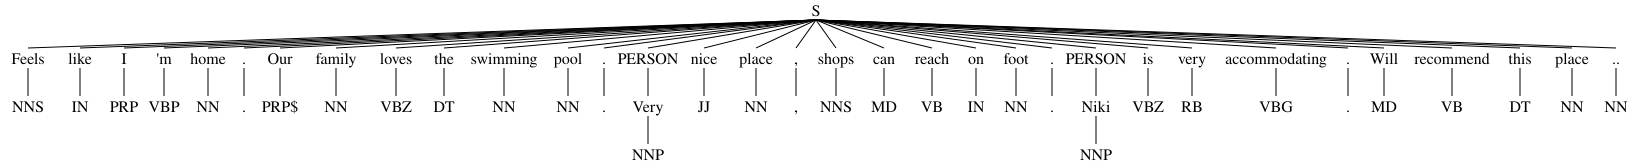

In [21]:
display(entities)